**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC5053 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 6**
Ingeniería de características (FE)

---

*   NOMBRE: Ernesto García González
*   MATRÍCULA: A00827434

En esta actividad trabajarás con el archivo `computer_prices.csv`, basado en un conjunto de datos sobre características técnicas y especificaciones de computadoras portátiles y de escritorio, disponible en Kaggle.

Los datos fueron recopilados para analizar el rendimiento y el precio de los dispositivos, e incluyen información sobre hardware, almacenamiento, conectividad y otras especificaciones técnicas. Los indicadores incluidos son:

* `device_type`: Tipo de dispositivo (ej. laptop, desktop)
* `brand`: Marca del dispositivo
* `model`: Modelo del dispositivo
* `release_year`: Año de lanzamiento del dispositivo
* `os`: Sistema operativo instalado
* `form_factor`: Factor de forma o diseño del dispositivo (ej. laptop, ultrabook, desktop tower)
* `cpu_brand`: Marca del procesador
* `cpu_tier`: Nivel o gama del procesador, ordinal del 1 al 6 según desempeño
* `cpu_cores`: Número de núcleos del procesador
* `cpu_threads`: Número de hilos de ejecución del procesador
* `gpu_brand`: Marca de la tarjeta gráfica
* `gpu_model`: Modelo específico de la tarjeta gráfica
* `gpu_tier`: Nivel o gama de la GPU, ordinal del 1 al 6 según desempeño
* `vram_gb`: Memoria de video de la GPU en gigabytes
* `ram_gb`: Memoria RAM del dispositivo en gigabytes
* `storage_type`: Tipo de almacenamiento (ej. HDD, SSD)
* `storage_gb`: Capacidad de almacenamiento en gigabytes
* `storage_drive_count`: Número de unidades de almacenamiento instaladas
* `display_type`: Tipo de pantalla (ej. IPS, TN, OLED)
* `charger_watts`: Potencia del cargador (en watts) para laptops
* `psu_watts`: Potencia de la fuente de poder (en watts) para desktops
* `wifi`: Estándar de conectividad Wi-Fi (ej. Wi-Fi 5, 6, 6E, 7)
* `bluetooth`: Versión de Bluetooth
* `weight_kg`: Peso del dispositivo en kilogramos
* `warranty_months`: Meses de garantía del dispositivo
* `price`: Precio del dispositivo. Es la variable de salida o *target*, es decir, la que se pretende predecir más adelante al construir el modelo.

**NOTA IMPORTANTE:** Asegúrate de responder *explícitamente* todos los cuestionamientos.

In [2]:
# Instalar las bibliotecas necesarias
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 3.5 MB/s eta 0:00:00


In [11]:
# Importar las bibliotecas necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date
from scipy.stats import probplot
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.preprocessing import FunctionTransformer, PowerTransformer
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from category_encoders.binary import BinaryEncoder

In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [31]:
import os
DIR = "/content/drive/MyDrive/Colab Notebooks/MNA/1er Trimestre/Ciencia y Analítica de Datos/6.1 FE"
os.chdir(DIR)

1. Descarga el archivo: `computer_prices.csv` y guarda, en un dataframe (`compu_df`), todos sus registros.
* Utiliza el método `info()` del dataframe, para obtener el resumen de los tipos de datos. ¿Cuántas columnas son numéricas y cuántas de texto?
* Determina la cantidad de valores únicos por columna.
* Elimina las variables:
  * `model`: Debido a su altísima cardinalidad, lo que dificulta su uso en análisis y modelado.
  * `cpu_model`: Además de su elevada cardinalidad, su información ya está representada de manera implícita en otras variables como: `cpu_tier`, `cpu_cores` y `cpu_threads`

In [32]:
compu_df = pd.read_csv('computer_prices.csv')

# Mostrar el resumen de tipos de datos
print("Resumen de tipos de datos:")
compu_df.info()

# Determinar cuántas columnas son numéricas y cuántas de texto
columnas_numericas = compu_df.select_dtypes(include=np.number).shape[1]
columnas_texto = compu_df.select_dtypes(include='object').shape[1]

print(f"\nCantidad de columnas numéricas: {columnas_numericas}")
print(f"Cantidad de columnas de texto: {columnas_texto}")

# Determinar la cantidad de valores únicos por columna
print("\nCantidad de valores únicos por columna:")
print(compu_df.nunique())

# Eliminar las variables 'model' y 'cpu_model'
compu_df = compu_df.drop(['model', 'cpu_model'], axis=1)

print("\nColumnas después de eliminar 'model' y 'cpu_model':")
print(compu_df.columns)

Resumen de tipos de datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 27 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   device_type          100000 non-null  object 
 1   brand                100000 non-null  object 
 2   model                100000 non-null  object 
 3   release_year         100000 non-null  int64  
 4   os                   100000 non-null  object 
 5   form_factor          100000 non-null  object 
 6   cpu_brand            100000 non-null  object 
 7   cpu_model            100000 non-null  object 
 8   cpu_tier             100000 non-null  int64  
 9   cpu_cores            100000 non-null  int64  
 10  cpu_threads          100000 non-null  int64  
 11  gpu_brand            100000 non-null  object 
 12  gpu_model            100000 non-null  object 
 13  gpu_tier             100000 non-null  int64  
 14  vram_gb              100000 non-null  int6

2. Antes de iniciar con el análisis univariado, verifica si hay valores duplicados y/o faltantes.
* Obtén las estadísticas descriptivas, separado las numéricas y las categóricas. De estas últimas incluye las tablas de frecuencia.
* Genera histogramas para las numéricas y diagramas de barras para las categóricas. Con alta cardinalidad, sólo incluye los 10 valores más frecuentes.

Cantidad de filas duplicadas: 0

Valores faltantes por columna:
device_type            0
brand                  0
release_year           0
os                     0
form_factor            0
cpu_brand              0
cpu_tier               0
cpu_cores              0
cpu_threads            0
gpu_brand              0
gpu_model              0
gpu_tier               0
vram_gb                0
ram_gb                 0
storage_type           0
storage_gb             0
storage_drive_count    0
display_type           0
charger_watts          0
psu_watts              0
wifi                   0
bluetooth              0
weight_kg              0
warranty_months        0
price                  0
dtype: int64

Estadísticas descriptivas para columnas numéricas:
        release_year       cpu_tier      cpu_cores    cpu_threads  \
count  100000.000000  100000.000000  100000.000000  100000.000000   
mean     2022.320850       3.153490      10.515740      19.372700   
std         2.025761       1.373175    

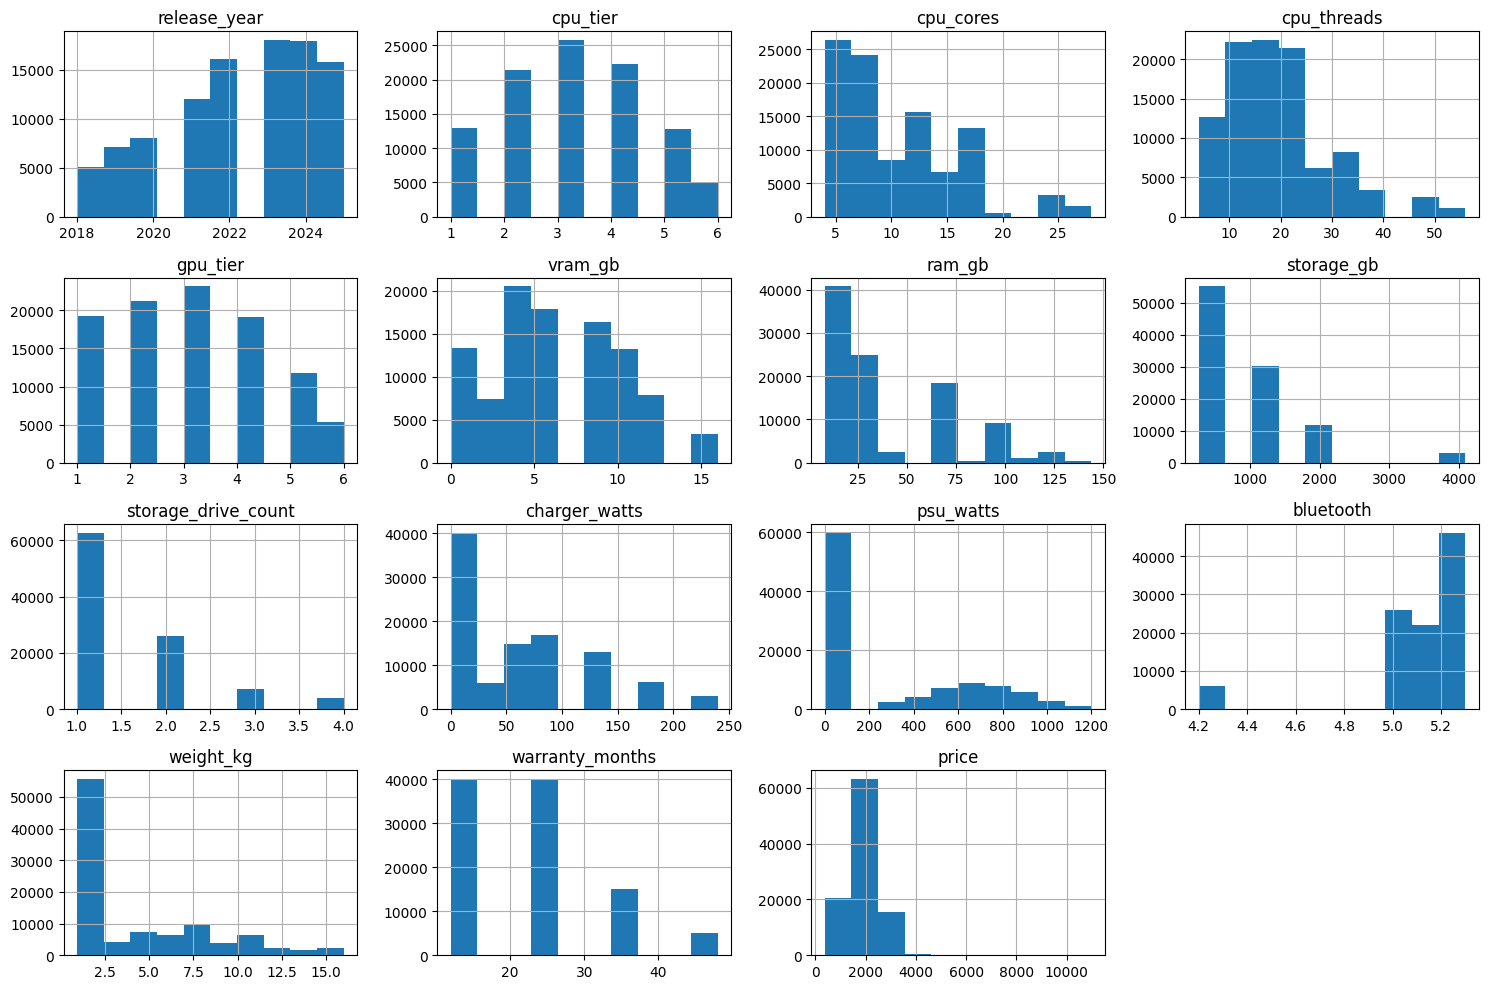


Diagramas de barras para variables categóricas:


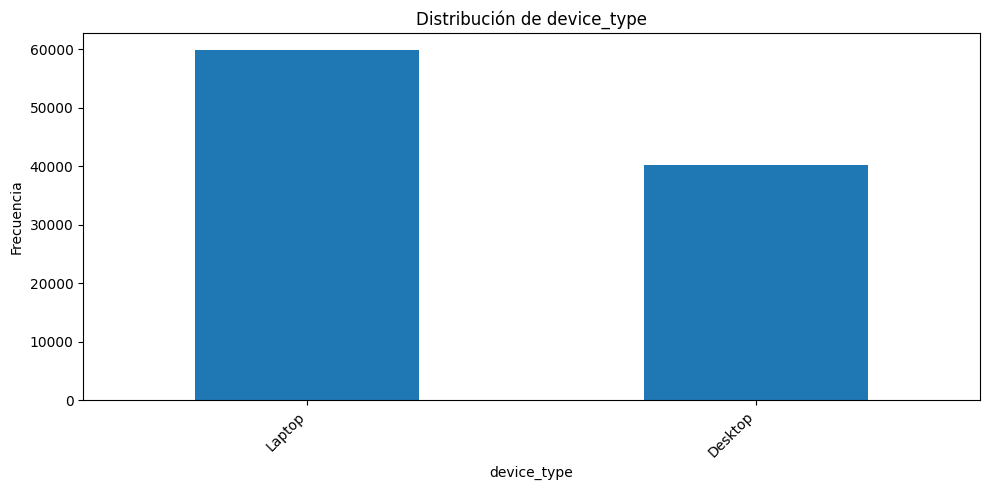

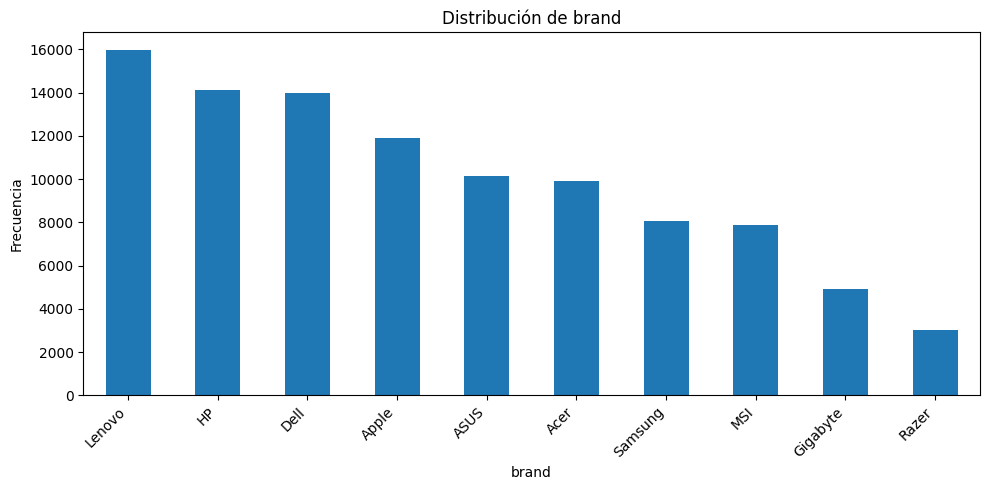

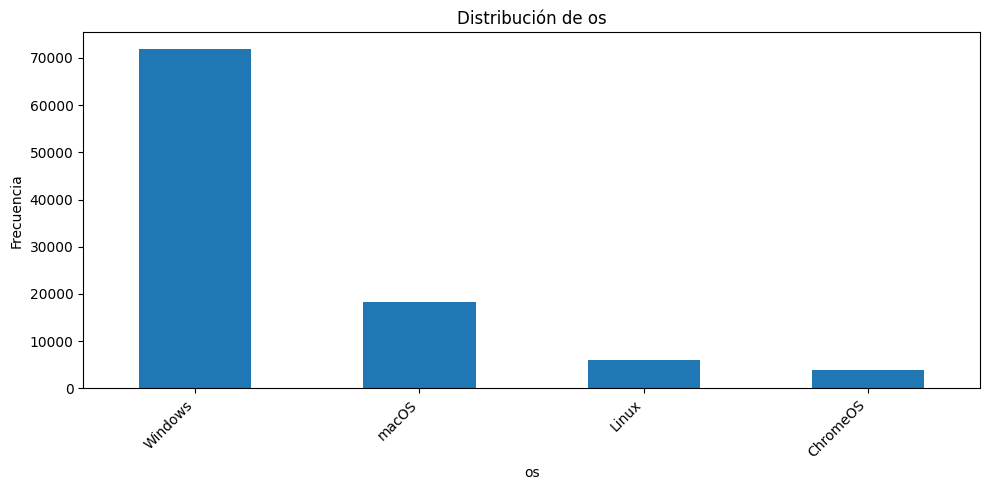

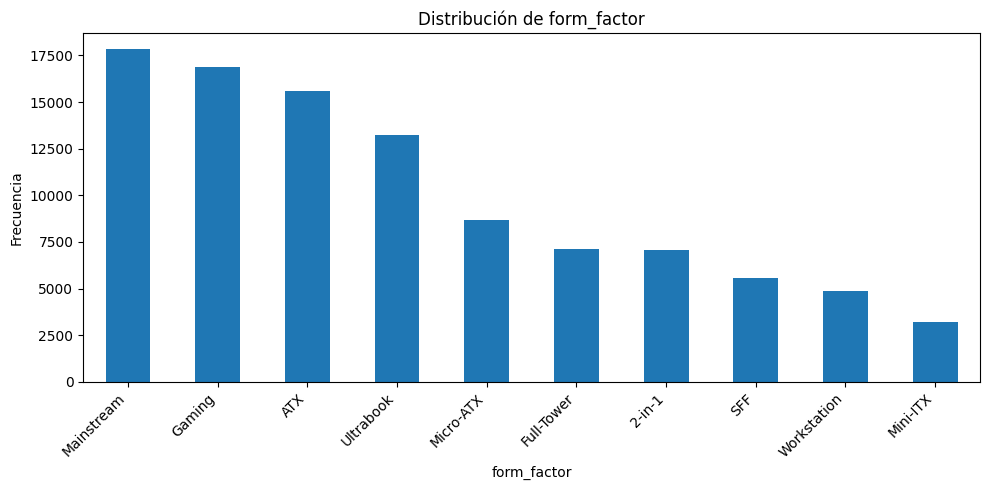

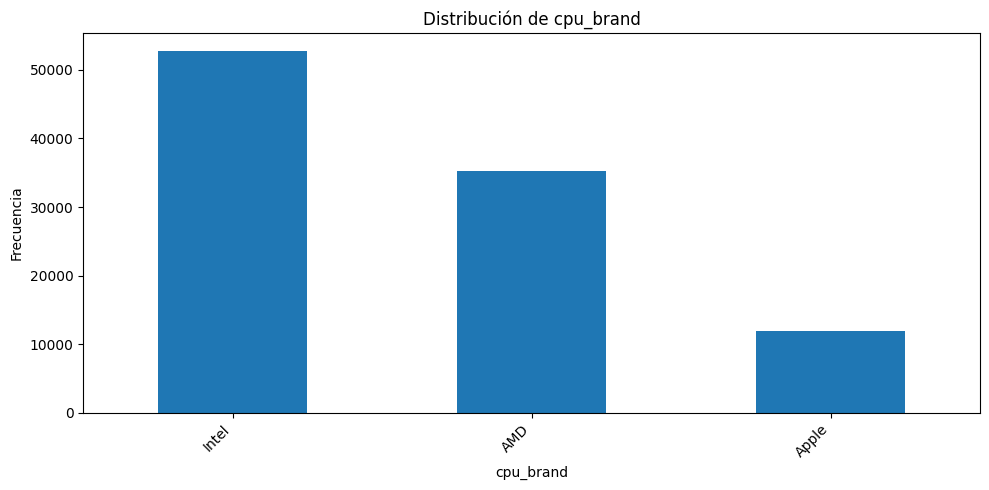

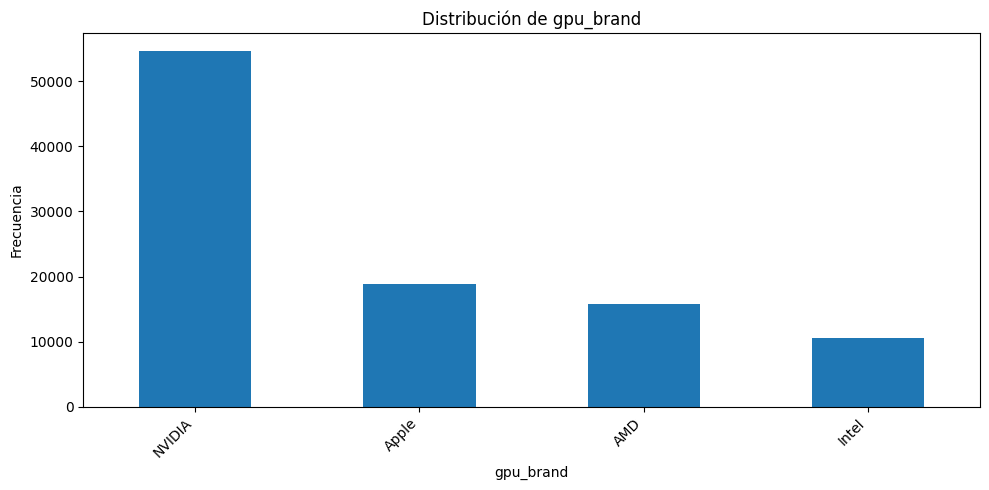

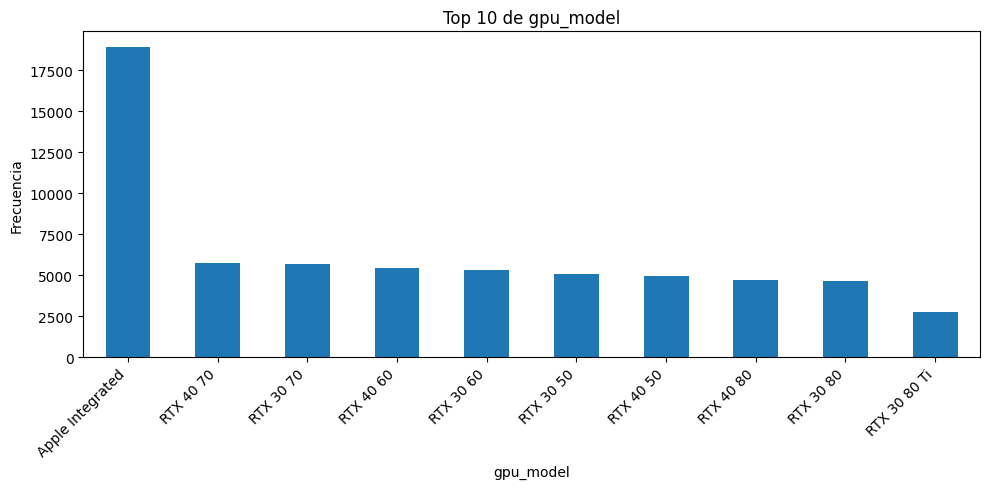

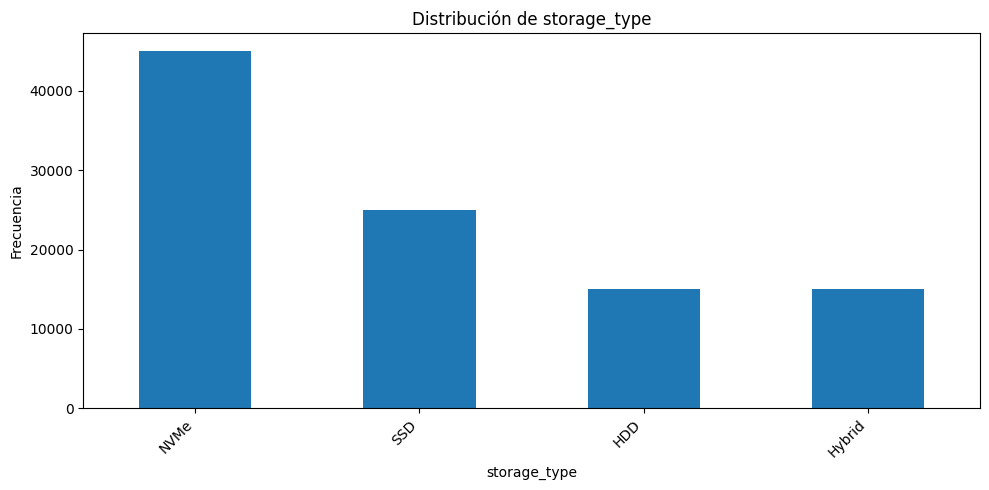

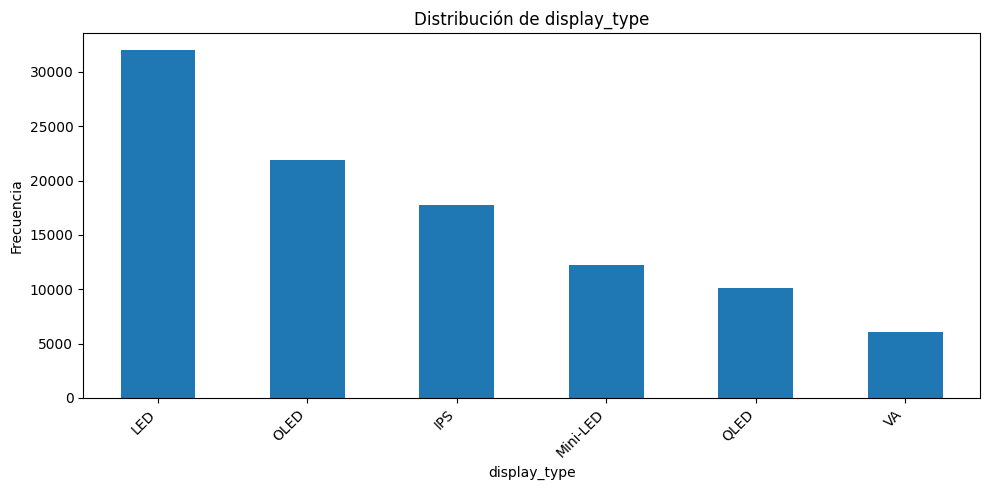

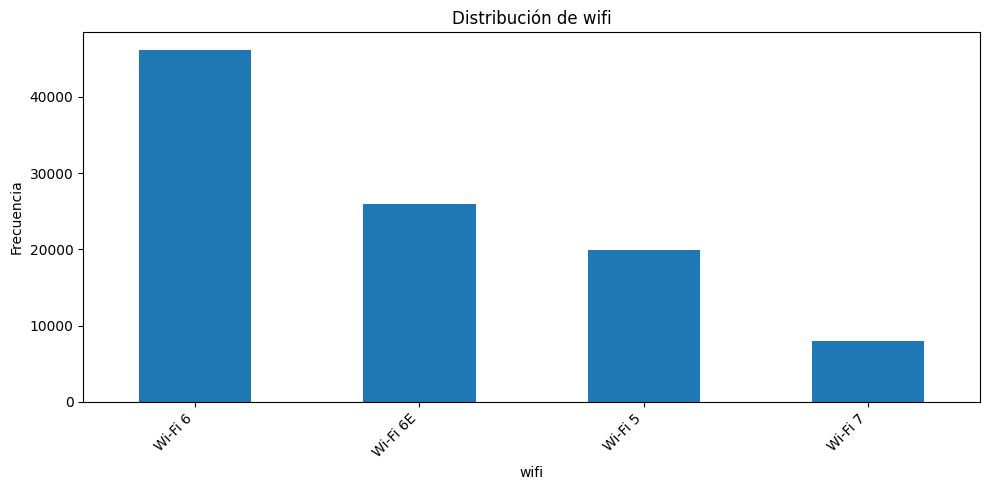

In [33]:
# Verificar si hay valores duplicados
print("Cantidad de filas duplicadas:", compu_df.duplicated().sum())

# Verificar si hay valores faltantes por columna
print("\nValores faltantes por columna:")
print(compu_df.isnull().sum())

# Obtener estadísticas descriptivas para columnas numéricas
print("\nEstadísticas descriptivas para columnas numéricas:")
print(compu_df.select_dtypes(include=np.number).describe())

# Obtener estadísticas descriptivas para columnas categóricas
print("\nEstadísticas descriptivas para columnas categóricas:")
print(compu_df.select_dtypes(include='object').describe())

# Tablas de frecuencia para columnas categóricas
print("\nTablas de frecuencia para columnas categóricas:")
for col in compu_df.select_dtypes(include='object').columns:
    print(f"\nTabla de frecuencia para '{col}':")
    print(compu_df[col].value_counts())

# Generar histogramas para variables numéricas
compu_df.select_dtypes(include=np.number).hist(figsize=(15, 10))
plt.tight_layout()
plt.show()

# Generar diagramas de barras para variables categóricas (solo top 10 si tienen alta cardinalidad)
print("\nDiagramas de barras para variables categóricas:")
for col in compu_df.select_dtypes(include='object').columns:
    plt.figure(figsize=(10, 5))
    if compu_df[col].nunique() > 10:
        # Mostrar solo el top 10 si hay alta cardinalidad
        compu_df[col].value_counts().nlargest(10).plot(kind='bar')
        plt.title(f'Top 10 de {col}')
    else:
        compu_df[col].value_counts().plot(kind='bar')
        plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

3. Dibuja un mapa de calor con la matriz de correlación para las variables numéricas del conjunto de datos.
* Identifica los pares de variables cuya correlación sea superior a 0.9 e imprímelos.
* Reflexiona sobre cuáles variables representan de manera general la capacidad del hardware y mantenlas; elimina las demás por aportar información redundante.
* Incluye una breve justificación de tus decisiones.

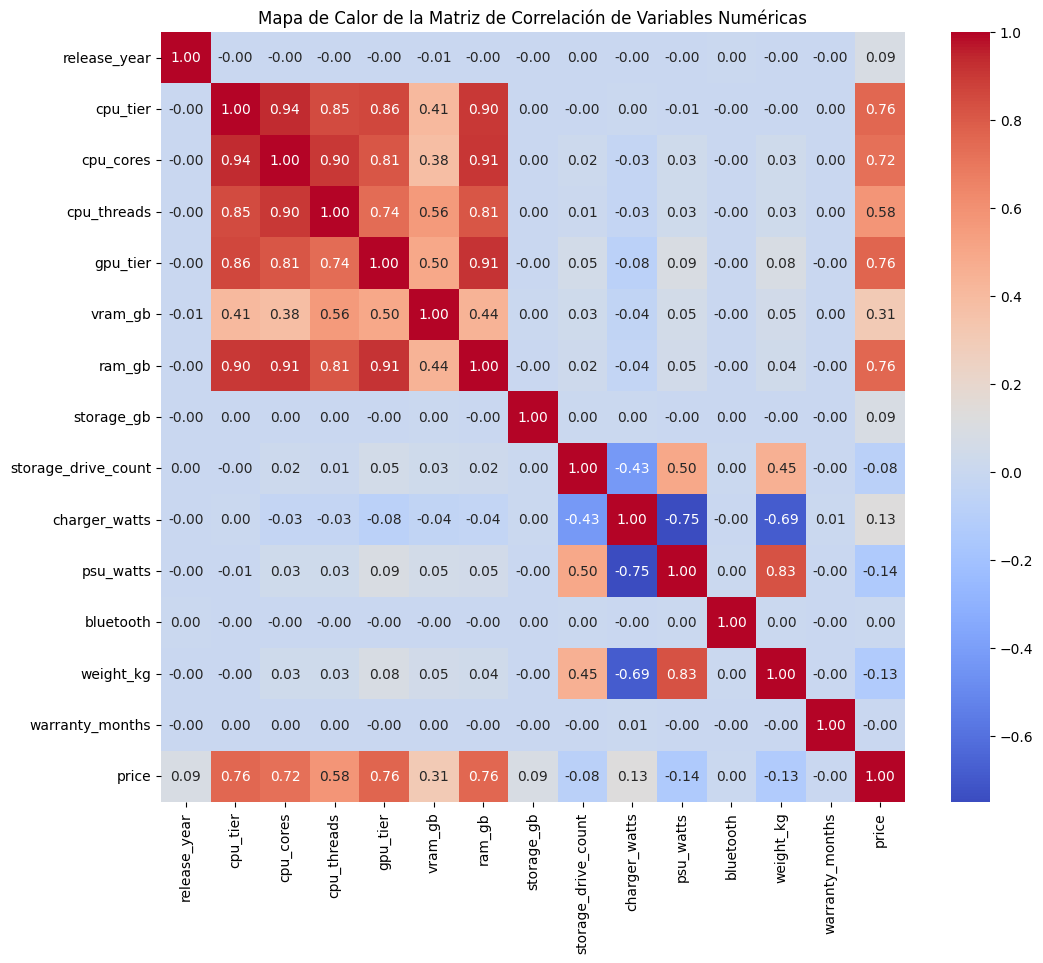


Pares de variables con correlación superior a 0.9:
cpu_tier - cpu_cores: 0.94
cpu_cores - ram_gb: 0.91
gpu_tier - ram_gb: 0.91


In [34]:
# Calcular la matriz de correlación para las variables numéricas
corr_matrix = compu_df.select_dtypes(include=np.number).corr()

# Dibujar el mapa de calor
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Mapa de Calor de la Matriz de Correlación de Variables Numéricas")
plt.show()

# Identificar pares de variables con correlación superior a 0.9
print("\nPares de variables con correlación superior a 0.9:")
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.9:
            colname_i = corr_matrix.columns[i]
            colname_j = corr_matrix.columns[j]
            high_corr_pairs.append((colname_j, colname_i, corr_matrix.iloc[i, j]))

for pair in high_corr_pairs:
    print(f"{pair[0]} - {pair[1]}: {pair[2]:.2f}")

In [35]:
# Identificar las variables que representan la capacidad del hardware
# Basado en la descripción de los datos y el conocimiento general de hardware.
hardware_cols = [
    'cpu_brand',
    'cpu_tier',
    'cpu_threads',
    'gpu_brand',
    'gpu_model',
    'gpu_tier',
    'vram_gb',
    'ram_gb',
    'storage_type',
    'storage_gb',
    'storage_drive_count',
    'charger_watts',
    'psu_watts',
    'weight_kg',
    'release_year',
    'wifi',
    'price'
    # 'os', 'form_factor', 'display_type', 'bluetooth', 'warranty_months'
    # Estas variables no representan directamente la *capacidad* de hardware, sino características, software, conectividad o garantía.
]

# Eliminar las columnas que no representan la capacidad de hardware
all_cols = compu_df.columns.tolist()
cols_to_drop = [col for col in all_cols if col not in hardware_cols]

compu_df = compu_df.drop(columns=cols_to_drop)

print("Columnas restantes después de eliminar variables no relacionadas con hardware:")
print(compu_df.columns)

Columnas restantes después de eliminar variables no relacionadas con hardware:
Index(['release_year', 'cpu_brand', 'cpu_tier', 'cpu_threads', 'gpu_brand',
       'gpu_model', 'gpu_tier', 'vram_gb', 'ram_gb', 'storage_type',
       'storage_gb', 'storage_drive_count', 'charger_watts', 'psu_watts',
       'wifi', 'weight_kg', 'price'],
      dtype='object')


4. Para comenzar con la ingeniería de características, crea una copia del dataframe y asígnala a un nuevo objeto llamado `compu_trans`.
* Calcula cuántos años han pasado desde el lanzamiento de cada computadora y almacénalo en una nueva columna llamada `years_since_release`; luego, elimina la columna original.
* Utiliza `KBinsDiscretizer` para reemplazar la columna `vram_gb` en 4 bins ordinales basados en cuantiles.
* Imprime los valores que delimitan cada bin y haz un histograma para ver la cantidad de observaciones en cada uno, con el fin de entender cómo se agruparon los datos.

Valores que delimitan cada bin para 'vram_gb':
[array([ 0.,  4.,  6.,  8., 16.])]


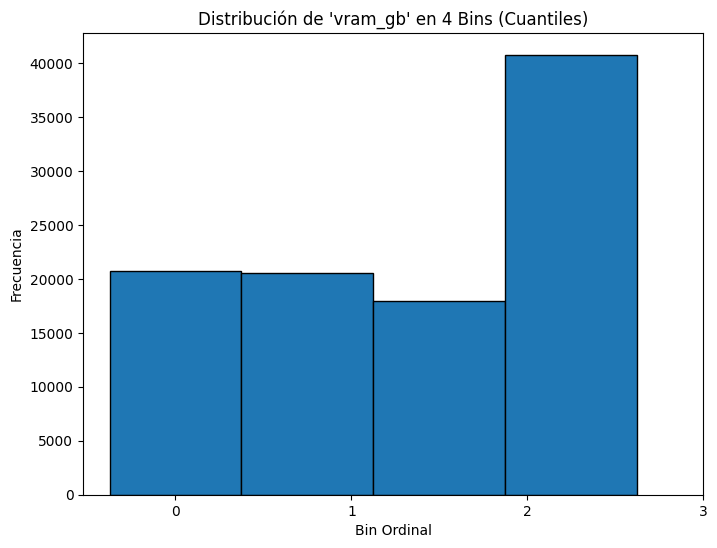


Primeras filas del dataframe con 'years_since_release' y 'vram_gb_binned':


,release_year,cpu_brand,cpu_tier,cpu_threads,gpu_brand,gpu_model,gpu_tier,vram_gb,ram_gb,storage_type,storage_gb,storage_drive_count,charger_watts,psu_watts,wifi,weight_kg,price,years_since_release,vram_gb_binned
0,2022,Intel,3,24,NVIDIA,RTX 40 60,2,6,16,NVMe,1024,1,0,750,Wi-Fi 6,11.00,1383.99,3,2.0
1,2022,Intel,4,24,NVIDIA,RTX 40 80,4,10,64,NVMe,512,1,120,0,Wi-Fi 6,2.03,2274.99,3,3.0
2,2024,AMD,2,16,NVIDIA,RTX 40 50,1,4,8,NVMe,512,2,0,850,Wi-Fi 6,7.00,1879.99,1,1.0
3,2024,AMD,2,12,AMD,RX 7000 60,2,6,16,HDD,512,2,0,650,Wi-Fi 6,6.00,1331.99,1,2.0
4,2024,AMD,5,32,NVIDIA,RTX 30 80 Ti,5,12,96,NVMe,256,1,90,0,Wi-Fi 6,1.50,2681.99,1,3.0


In [36]:
# Crear una copia del dataframe
compu_trans = compu_df.copy()

# Calcular años desde el lanzamiento
current_year = date.today().year
compu_trans['years_since_release'] = current_year - compu_trans['release_year']

# Eliminar la columna original 'release_year'
# compu_trans = compu_trans.drop('release_year', axis=1) # Esta linea fue eliminada ya que release_year fue eliminada en un paso anterior

# Utilizar KBinsDiscretizer para 'vram_gb'
# Asegurarse de que 'vram_gb' sea un array 2D para KBinsDiscretizer
vram_gb_data = compu_trans['vram_gb'].values.reshape(-1, 1)

discretizer = KBinsDiscretizer(n_bins=4, encode='ordinal', strategy='quantile')
compu_trans['vram_gb_binned'] = discretizer.fit_transform(vram_gb_data)

# Imprimir los valores que delimitan cada bin
print("Valores que delimitan cada bin para 'vram_gb':")
print(discretizer.bin_edges_)

# Hacer un histograma para ver la cantidad de observaciones en cada bin
plt.figure(figsize=(8, 6))
plt.hist(compu_trans['vram_gb_binned'], bins=4, edgecolor='black', align='left')
plt.xticks([0, 1, 2, 3]) # Ajustar los ticks para que correspondan a los bins ordinales
plt.title("Distribución de 'vram_gb' en 4 Bins (Cuantiles)")
plt.xlabel("Bin Ordinal")
plt.ylabel("Frecuencia")
plt.show()

# Opcional: Mostrar las primeras filas para verificar la nueva columna
print("\nPrimeras filas del dataframe con 'years_since_release' y 'vram_gb_binned':")
display(compu_trans.head())

5. Observa los histogramas del ejercicio 2. Notarás que en las variables `charger_watts` y `psu_watts` aparece una barra en 0. Analiza por qué ocurre esto y qué significa en relación con el tipo de dispositivo.
* Como estas variables son mutuamente excluyentes, combínalas en una nueva columna llamada `power_watts` que contenga la potencia correspondiente de cada dispositivo y, a continuación, haz un histograma para verificar que la distribución resultante es bimodal.
* Por último, borra las columnas originales `charger_watts` y `psu_watts`.

Observación: Se espera que las laptops tengan charger_watts > 0 y psu_watts = 0,
mientras que las desktops tengan charger_watts = 0 y psu_watts > 0.
Los 0s en los histogramas indican que para un tipo de dispositivo, la otra variable de potencia es cero.

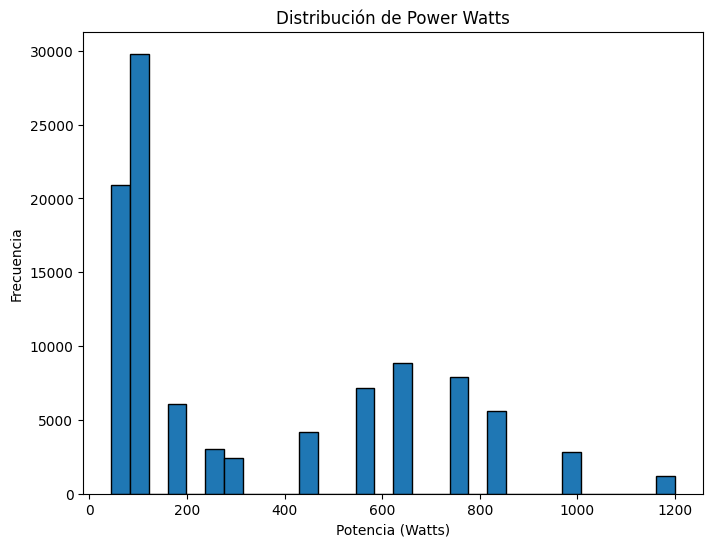


Columnas después de combinar y eliminar charger_watts y psu_watts:
Index(['release_year', 'cpu_brand', 'cpu_tier', 'cpu_threads', 'gpu_brand',
       'gpu_model', 'gpu_tier', 'vram_gb', 'ram_gb', 'storage_type',
       'storage_gb', 'storage_drive_count', 'wifi', 'weight_kg', 'price',
       'years_since_release', 'vram_gb_binned', 'power_watts'],
      dtype='object')


In [37]:
# Combinar charger_watts y psu_watts en power_watts
compu_trans['power_watts'] = compu_trans['charger_watts'] + compu_trans['psu_watts']

# Hacer un histograma para verificar que la distribución resultante es bimodal
plt.figure(figsize=(8, 6))
plt.hist(compu_trans['power_watts'], bins=30, edgecolor='black')
plt.title("Distribución de Power Watts")
plt.xlabel("Potencia (Watts)")
plt.ylabel("Frecuencia")
plt.show()

# Borrar las columnas originales charger_watts y psu_watts
compu_trans = compu_trans.drop(['charger_watts', 'psu_watts'], axis=1)

print("\nColumnas después de combinar y eliminar charger_watts y psu_watts:")
print(compu_trans.columns)

6. Para disminuir el sesgo de la variable `price`, crea tres transformadores: logaritmo, raíz cuadrada y Box - Cox.
* Aplica cada transformador a la variable price, dejando el resultado en variables temporales. El objetivo es comparar los efectos de cada transformación antes de decidir cuál aplicar de manera definitiva sobre las variables continuas del dataframe.
* De la variable original y de cada una de las tres transformaciones se debe mostrar:
  * Histograma: para observar la distribución de los datos.
  * Boxplot: para identificar posibles valores atípicos.
  * Q-Q plot: para evaluar la normalidad de la variable.
  * Skew (sesgo): para cuantificar la asimetría de la distribución.
  * Cantidad de outliers: para conocer cuántos valores extremos existen.
* En función de los resultados obtenidos al comparar las transformaciones, decide cuál logró el mejor efecto sobre la distribución de la variable y aplícala directamente en el dataframe, reemplazando las variables continuas: `weight_kg`, `power_watts` y `price`.


--- Análisis de 'price Original' ---


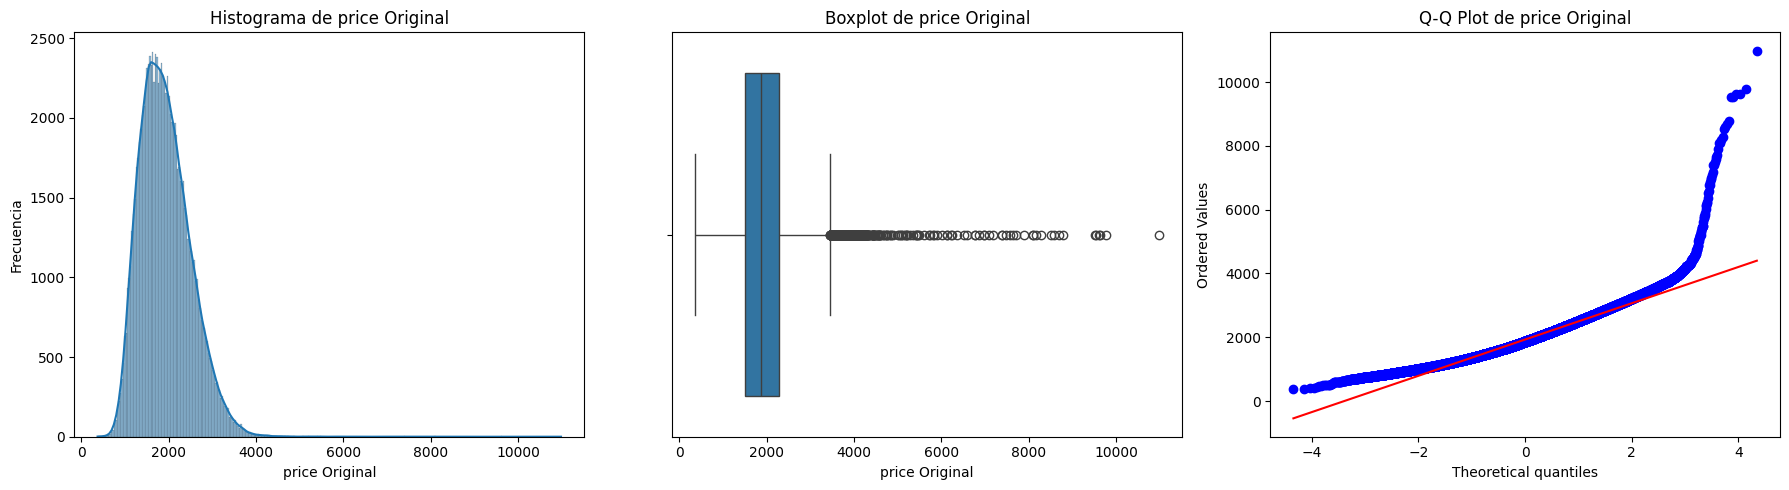

Sesgo (Skewness): 0.99
Cantidad de outliers (IQR): 976

--- Análisis de 'price Transformado (Logaritmo)' ---


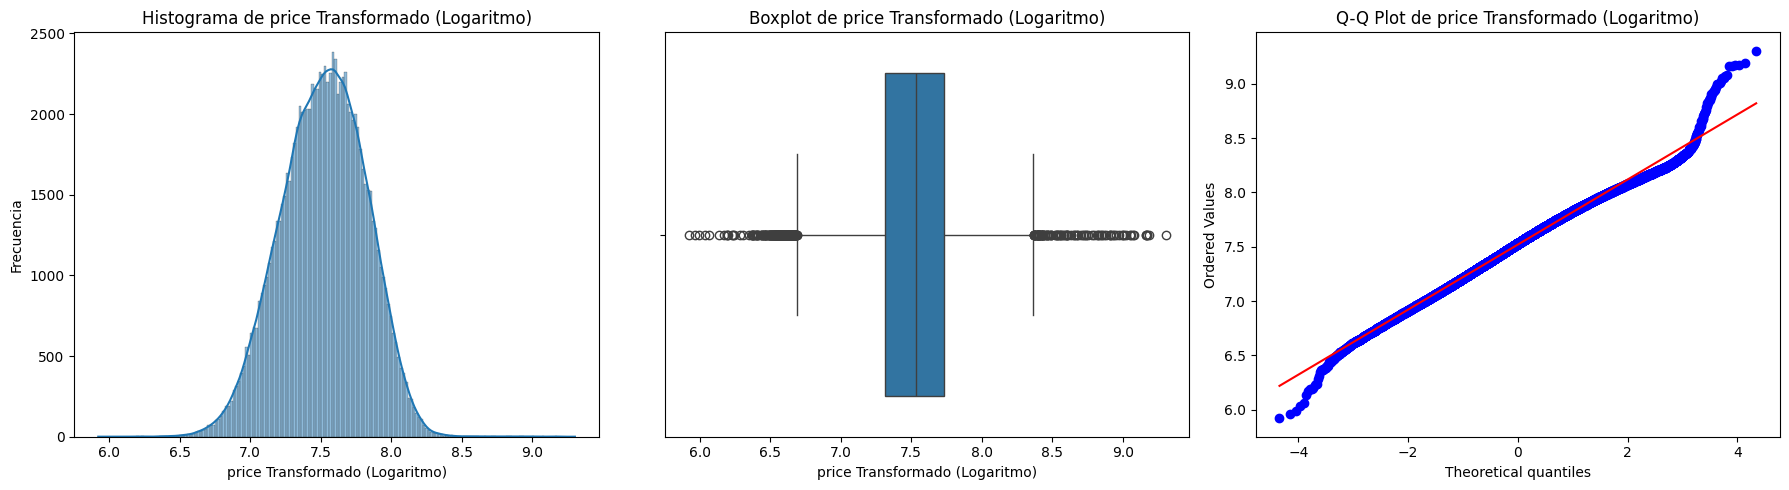

Sesgo (Skewness): -0.13
Cantidad de outliers (IQR): 386

--- Análisis de 'price Transformado (Raíz Cuadrada)' ---


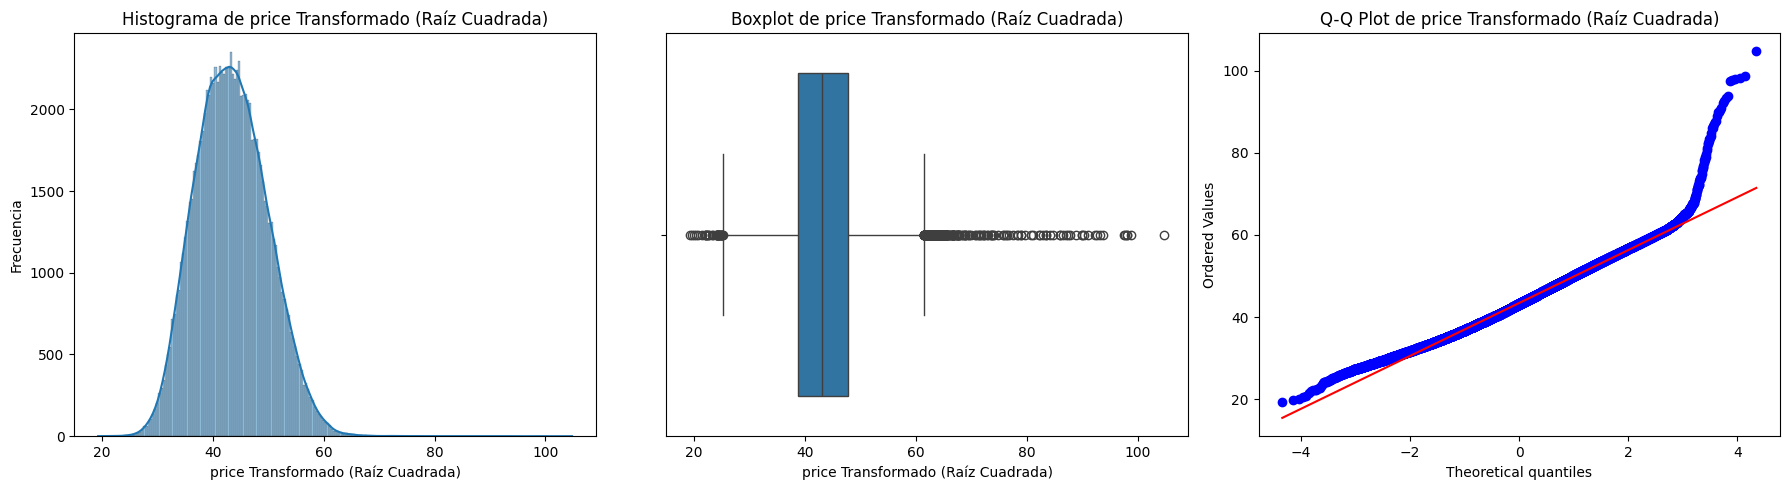

Sesgo (Skewness): 0.33
Cantidad de outliers (IQR): 364

--- Análisis de 'price Transformado (Box-Cox)' ---


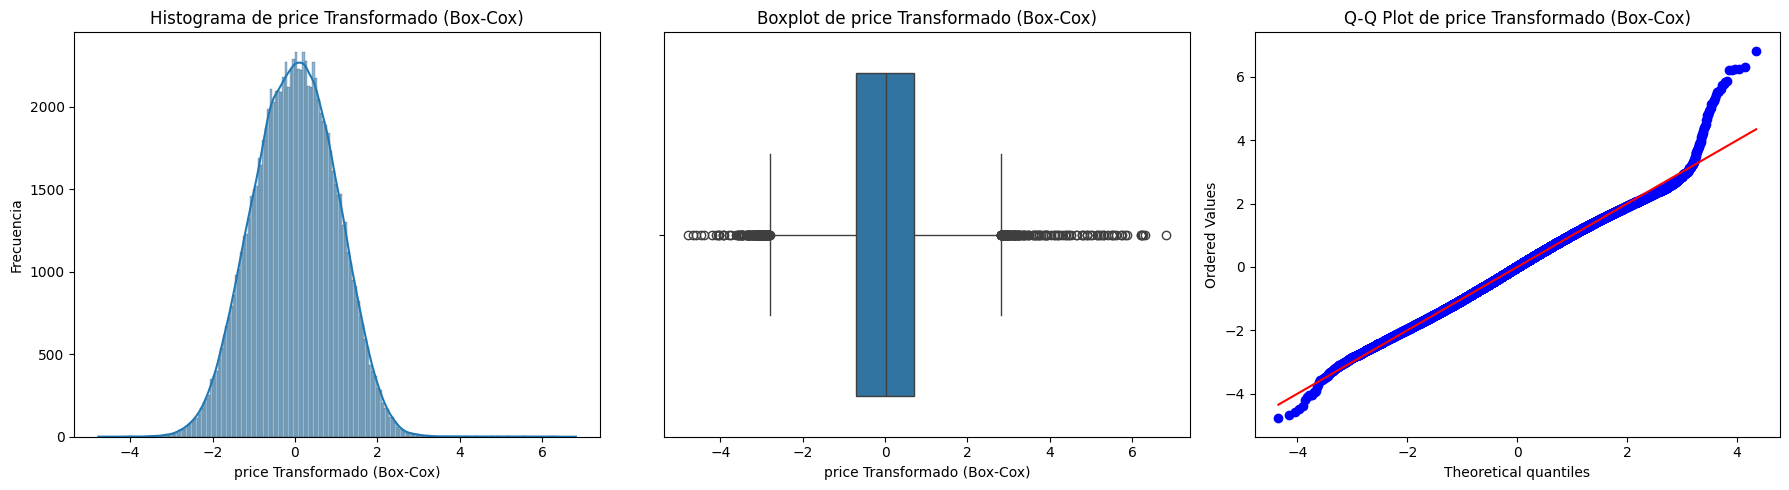

Sesgo (Skewness): -0.00
Cantidad de outliers (IQR): 317


In [38]:
# Crear transformadores
log_transformer = FunctionTransformer(np.log)
sqrt_transformer = FunctionTransformer(np.sqrt)
boxcox_transformer = PowerTransformer(method='box-cox')

# Aplicar transformaciones a la variable 'price'
price_original = compu_trans['price']
price_log = log_transformer.fit_transform(price_original.values.reshape(-1, 1)).flatten()
price_sqrt = sqrt_transformer.fit_transform(price_original.values.reshape(-1, 1)).flatten()
price_boxcox = boxcox_transformer.fit_transform(price_original.values.reshape(-1, 1)).flatten()

# Función para mostrar visualizaciones y métricas
def plot_and_metrics(data, title):
    print(f"\n--- Análisis de '{title}' ---")

    # Histograma
    plt.figure(figsize=(18, 5))
    plt.subplot(1, 3, 1)
    sns.histplot(data, kde=True)
    plt.title(f'Histograma de {title}')
    plt.xlabel(title)
    plt.ylabel("Frecuencia")

    # Boxplot
    plt.subplot(1, 3, 2)
    sns.boxplot(x=data)
    plt.title(f'Boxplot de {title}')
    plt.xlabel(title)

    # Q-Q plot
    plt.subplot(1, 3, 3)
    probplot(data, dist="norm", plot=plt)
    plt.title(f'Q-Q Plot de {title}')

    plt.tight_layout()
    plt.show()

    # Skewness
    skewness = pd.Series(data).skew()
    print(f"Sesgo (Skewness): {skewness:.2f}")

    # Cantidad de outliers (usando IQR)
    Q1 = pd.Series(data).quantile(0.25)
    Q3 = pd.Series(data).quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers_count = ((data < lower_bound) | (data > upper_bound)).sum()
    print(f"Cantidad de outliers (IQR): {outliers_count}")


# Mostrar visualizaciones y métricas para cada versión de 'price'
plot_and_metrics(price_original, 'price Original')
plot_and_metrics(price_log, 'price Transformado (Logaritmo)')
plot_and_metrics(price_sqrt, 'price Transformado (Raíz Cuadrada)')
plot_and_metrics(price_boxcox, 'price Transformado (Box-Cox)')

In [39]:
# Variables continuas a transformar
continuous_cols = ['weight_kg', 'power_watts', 'price']

# Aplicar la transformación Box-Cox a las variables continuas
pt = PowerTransformer(method='box-cox')
compu_trans[continuous_cols] = pt.fit_transform(compu_trans[continuous_cols])

print("\nDataFrame después de aplicar la transformación Box-Cox a variables continuas:")
display(compu_trans[continuous_cols].head())

# Verificar el sesgo después de la transformación
print("\nSesgo después de la transformación:")
print(compu_trans[continuous_cols].skew())


DataFrame después de aplicar la transformación Box-Cox a variables continuas:


,weight_kg,power_watts,price
0,1.414935,1.237543,-0.963720
1,-0.317348,-0.452916,0.688630
2,1.079395,1.335405,0.039949
3,0.947251,1.123151,-1.085989
4,-0.804845,-0.767853,1.263601



Sesgo después de la transformación:
weight_kg      0.213748
power_watts    0.086581
price         -0.000238
dtype: float64


7. Para que todas las variables numéricas estén en la misma escala, aplica `MinMaxScaler` de sklearn a todas las columnas numéricas del dataframe, reemplazando las columnas originales.

In [40]:
# Seleccionar todas las columnas numéricas
numerical_cols = compu_trans.select_dtypes(include=np.number).columns

# Aplicar MinMaxScaler a las columnas numéricas
scaler = MinMaxScaler()
compu_trans[numerical_cols] = scaler.fit_transform(compu_trans[numerical_cols])

print("DataFrame después de aplicar MinMaxScaler a variables numéricas:")
display(compu_trans.head())

# Verificar las estadísticas descriptivas para confirmar la escala
print("\nEstadísticas descriptivas de variables numéricas después de escalar:")
display(compu_trans[numerical_cols].describe())

DataFrame después de aplicar MinMaxScaler a variables numéricas:


,release_year,cpu_brand,cpu_tier,cpu_threads,gpu_brand,gpu_model,gpu_tier,vram_gb,ram_gb,storage_type,storage_gb,storage_drive_count,wifi,weight_kg,price,years_since_release,vram_gb_binned,power_watts
0,0.571429,Intel,0.4,0.384615,NVIDIA,RTX 40 60,0.2,0.375,0.058824,NVMe,0.200000,0.000000,Wi-Fi 6,0.932995,0.328669,0.428571,0.666667,0.887860
1,0.571429,Intel,0.6,0.384615,NVIDIA,RTX 40 80,0.6,0.625,0.411765,NVMe,0.066667,0.000000,Wi-Fi 6,0.423737,0.471202,0.428571,1.000000,0.357238
2,0.857143,AMD,0.2,0.230769,NVIDIA,RTX 40 50,0.0,0.250,0.000000,NVMe,0.066667,0.333333,Wi-Fi 6,0.834353,0.415246,0.142857,0.333333,0.918578
3,0.857143,AMD,0.2,0.153846,AMD,RX 7000 60,0.2,0.375,0.058824,HDD,0.066667,0.333333,Wi-Fi 6,0.795505,0.318122,0.142857,0.666667,0.851953
4,0.857143,AMD,0.8,0.538462,NVIDIA,RTX 30 80 Ti,0.8,0.750,0.647059,NVMe,0.000000,0.000000,Wi-Fi 6,0.280423,0.520800,0.142857,1.000000,0.258382



Estadísticas descriptivas de variables numéricas después de escalar:


,release_year,cpu_tier,cpu_threads,gpu_tier,vram_gb,ram_gb,storage_gb,storage_drive_count,weight_kg,price,years_since_release,vram_gb_binned,power_watts
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.617264,0.430698,0.295629,0.398270,0.384511,0.233135,0.168733,0.174993,0.517032,0.411800,0.382736,0.595883,0.499405
std,0.289394,0.274635,0.186893,0.291929,0.247808,0.234579,0.201626,0.265761,0.293982,0.086261,0.289394,0.394170,0.313894
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.428571,0.200000,0.153846,0.200000,0.250000,0.058824,0.066667,0.000000,0.280423,0.351779,0.142857,0.333333,0.258382
50%,0.714286,0.400000,0.230769,0.400000,0.375000,0.176471,0.066667,0.000000,0.417162,0.412776,0.285714,0.666667,0.357238
75%,0.857143,0.600000,0.384615,0.600000,0.500000,0.411765,0.200000,0.333333,0.834353,0.472899,0.571429,1.000000,0.851953
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


8. Aunque `wifi` es una variable categórica, sus categorías tienen un orden natural (Wi-Fi 5 < Wi-Fi 6 < Wi-Fi 6E < Wi-Fi 7). Codifícala usando `OrdinalEncoder`.
* Luego, escala la variable codificada entre 0 y 1 con `MinMaxScaler`, para que quede en la misma escala que las variables numéricas del dataframe.

Nota: Ambos cambios deben efectuarse sobre la columna original, de manera que quede una única columna `wifi` con toda la información transformada.

In [41]:
# Definir el orden de las categorías de 'wifi'
wifi_order = [['Wi-Fi 5', 'Wi-Fi 6', 'Wi-Fi 6E', 'Wi-Fi 7']]

# Inicializar y aplicar OrdinalEncoder
ordinal_encoder = OrdinalEncoder(categories=wifi_order, handle_unknown='use_encoded_value', unknown_value=-1)
compu_trans['wifi_encoded'] = ordinal_encoder.fit_transform(compu_trans[['wifi']])

# Escalar la columna codificada entre 0 y 1
scaler = MinMaxScaler()
compu_trans['wifi_scaled'] = scaler.fit_transform(compu_trans[['wifi_encoded']])

# Reemplazar la columna original 'wifi' con la columna escalada
compu_trans = compu_trans.drop('wifi', axis=1)
compu_trans = compu_trans.rename(columns={'wifi_scaled': 'wifi'})

# Eliminar la columna intermedia 'wifi_encoded' si ya no se necesita
compu_trans = compu_trans.drop('wifi_encoded', axis=1)

print("DataFrame después de codificar y escalar la columna 'wifi':")
display(compu_trans.head())

# Verificar las estadísticas descriptivas de la columna 'wifi' escalada
print("\nEstadísticas descriptivas de la columna 'wifi' después de escalar:")
display(compu_trans['wifi'].describe())

DataFrame después de codificar y escalar la columna 'wifi':


,release_year,cpu_brand,cpu_tier,cpu_threads,gpu_brand,gpu_model,gpu_tier,vram_gb,ram_gb,storage_type,storage_gb,storage_drive_count,weight_kg,price,years_since_release,vram_gb_binned,power_watts,wifi
0,0.571429,Intel,0.4,0.384615,NVIDIA,RTX 40 60,0.2,0.375,0.058824,NVMe,0.200000,0.000000,0.932995,0.328669,0.428571,0.666667,0.887860,0.333333
1,0.571429,Intel,0.6,0.384615,NVIDIA,RTX 40 80,0.6,0.625,0.411765,NVMe,0.066667,0.000000,0.423737,0.471202,0.428571,1.000000,0.357238,0.333333
2,0.857143,AMD,0.2,0.230769,NVIDIA,RTX 40 50,0.0,0.250,0.000000,NVMe,0.066667,0.333333,0.834353,0.415246,0.142857,0.333333,0.918578,0.333333
3,0.857143,AMD,0.2,0.153846,AMD,RX 7000 60,0.2,0.375,0.058824,HDD,0.066667,0.333333,0.795505,0.318122,0.142857,0.666667,0.851953,0.333333
4,0.857143,AMD,0.8,0.538462,NVIDIA,RTX 30 80 Ti,0.8,0.750,0.647059,NVMe,0.000000,0.000000,0.280423,0.520800,0.142857,1.000000,0.258382,0.333333



Estadísticas descriptivas de la columna 'wifi' después de escalar:


,wifi
count,100000.000000
mean,0.406670
std,0.284834
min,0.000000
25%,0.333333
50%,0.333333
75%,0.666667
max,1.000000


9. La variable `gpu_model` tiene muchas categorías. Usar *One-Hot Encoding* aumentaría significativamente la dimensionalidad del dataframe. Por ello, utiliza `BinaryEncoder` para codificarla.
* Guarda el resultado en un dataframe llamado `bin_df`. Más adelante, lo combinarás con `compu_transf` para integrar las variables codificadas.

In [42]:
# Inicializar y aplicar BinaryEncoder a la columna 'gpu_model'
binary_encoder = BinaryEncoder(cols=['gpu_model'])
bin_df = binary_encoder.fit_transform(compu_trans['gpu_model'])

print("Primeras filas del dataframe con la columna 'gpu_model' codificada con BinaryEncoder:")
display(bin_df.head())

print("\nColumnas generadas por BinaryEncoder:")
print(bin_df.columns)

Primeras filas del dataframe con la columna 'gpu_model' codificada con BinaryEncoder:


,gpu_model_0,gpu_model_1,gpu_model_2,gpu_model_3,gpu_model_4,gpu_model_5
0,0,0,0,0,0,1
1,0,0,0,0,1,0
2,0,0,0,0,1,1
3,0,0,0,1,0,0
4,0,0,0,1,0,1



Columnas generadas por BinaryEncoder:
Index(['gpu_model_0', 'gpu_model_1', 'gpu_model_2', 'gpu_model_3',
       'gpu_model_4', 'gpu_model_5'],
      dtype='object')


10. Usa `OneHotEncoder` para codificar las variables categóricas restantes. Asegúrate de usar `drop='first'` para evitar la multicolinealidad y guarda el resultado en un dataframe llamado `ohe_df`
* Combina el dataframe `compu_transf` con las variables categóricas que fueron codificadas en `bin_df` y `ohe_df`. No olvides eliminar las variables originales.
* Usa `describe()` sobre el dataframe resultante para corroborar que todas las columnas estén escaladas entre 0 y 1 y que no queden variables categóricas sin codificar.

In [43]:
# Seleccionar las variables categóricas restantes (excluyendo 'gpu_model' y 'wifi' que ya se manejaron)
categorical_cols = compu_trans.select_dtypes(include='object').columns.tolist()

# Inicializar y aplicar OneHotEncoder a las columnas categóricas restantes
ohe_encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
ohe_df = pd.DataFrame(ohe_encoder.fit_transform(compu_trans[categorical_cols]), columns=ohe_encoder.get_feature_names_out(categorical_cols))

print("Primeras filas del dataframe con las variables categóricas restantes codificadas con OneHotEncoder:")
display(ohe_df.head())

# Combinar el dataframe compu_trans con los dataframes codificados (bin_df y ohe_df)
compu_trans_reset = compu_trans.reset_index(drop=True)
bin_df_reset = bin_df.reset_index(drop=True)
ohe_df_reset = ohe_df.reset_index(drop=True)

compu_transf = pd.concat([compu_trans_reset, bin_df_reset, ohe_df_reset], axis=1)

# Eliminar las variables categóricas originales
compu_transf = compu_transf.drop(categorical_cols + ['gpu_model'], axis=1) # Eliminar gpu_model también

print("\nDataFrame final después de combinar y eliminar columnas originales:")
display(compu_transf.head())

# Usar describe() para corroborar que todas las columnas estén escaladas y que no queden variables categóricas
print("\nEstadísticas descriptivas del dataframe final:")
display(compu_transf.describe())

# Verificar si quedan columnas de tipo 'object'
print("\nColumnas restantes de tipo 'object':")
print(compu_transf.select_dtypes(include='object').columns)

Primeras filas del dataframe con las variables categóricas restantes codificadas con OneHotEncoder:


,cpu_brand_Apple,cpu_brand_Intel,gpu_brand_Apple,gpu_brand_Intel,gpu_brand_NVIDIA,storage_type_Hybrid,storage_type_NVMe,storage_type_SSD
0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
1,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
2,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0



DataFrame final después de combinar y eliminar columnas originales:


,release_year,cpu_tier,cpu_threads,gpu_tier,vram_gb,ram_gb,storage_gb,storage_drive_count,weight_kg,price,...,gpu_model_4,gpu_model_5,cpu_brand_Apple,cpu_brand_Intel,gpu_brand_Apple,gpu_brand_Intel,gpu_brand_NVIDIA,storage_type_Hybrid,storage_type_NVMe,storage_type_SSD
0,0.571429,0.4,0.384615,0.2,0.375,0.058824,0.200000,0.000000,0.932995,0.328669,...,0,1,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
1,0.571429,0.6,0.384615,0.6,0.625,0.411765,0.066667,0.000000,0.423737,0.471202,...,1,0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
2,0.857143,0.2,0.230769,0.0,0.250,0.000000,0.066667,0.333333,0.834353,0.415246,...,1,1,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,0.857143,0.2,0.153846,0.2,0.375,0.058824,0.066667,0.333333,0.795505,0.318122,...,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.857143,0.8,0.538462,0.8,0.750,0.647059,0.000000,0.000000,0.280423,0.520800,...,0,1,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0



Estadísticas descriptivas del dataframe final:


,release_year,cpu_tier,cpu_threads,gpu_tier,vram_gb,ram_gb,storage_gb,storage_drive_count,weight_kg,price,...,gpu_model_4,gpu_model_5,cpu_brand_Apple,cpu_brand_Intel,gpu_brand_Apple,gpu_brand_Intel,gpu_brand_NVIDIA,storage_type_Hybrid,storage_type_NVMe,storage_type_SSD
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.617264,0.430698,0.295629,0.398270,0.384511,0.233135,0.168733,0.174993,0.517032,0.411800,...,0.525590,0.686920,0.119150,0.527740,0.189220,0.105990,0.547120,0.149810,0.450590,0.249370
std,0.289394,0.274635,0.186893,0.291929,0.247808,0.234579,0.201626,0.265761,0.293982,0.086261,...,0.499347,0.463749,0.323967,0.499232,0.391685,0.307826,0.497777,0.356887,0.497555,0.432651
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.428571,0.200000,0.153846,0.200000,0.250000,0.058824,0.066667,0.000000,0.280423,0.351779,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.714286,0.400000,0.230769,0.400000,0.375000,0.176471,0.066667,0.000000,0.417162,0.412776,...,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
75%,0.857143,0.600000,0.384615,0.600000,0.500000,0.411765,0.200000,0.333333,0.834353,0.472899,...,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000



Columnas restantes de tipo 'object':
Index([], dtype='object')
